# Credit Card Fraud Detection

## Exploratory Data Analysis (EDA)

This notebook explores the transaction dataset to identify patterns, distributions, relationships, and characteristics associated with fraudulent transactions.

The analysis focuses on understanding how transaction behavior and features differ between legitimate and fraudulent transactions.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("/Users/cepl/Documents/Machine_Learning/Credit-Card-Fraud-Detection/dataset/card_transdata.csv")

In [20]:
df.head()


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [21]:
df.shape

(1000000, 8)

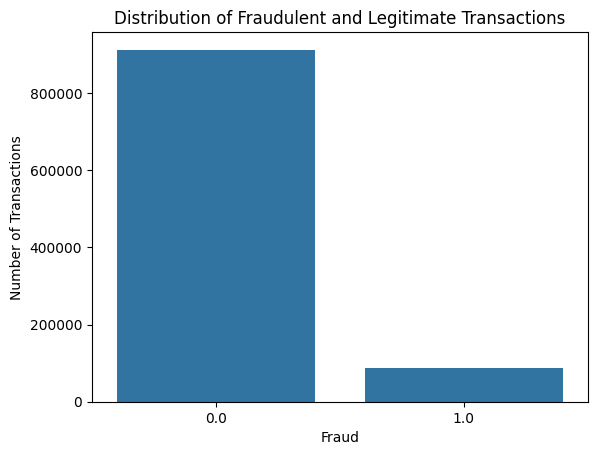

In [35]:

sns.countplot(data=df, x="fraud")

plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Fraud")
plt.ylabel("Number of Transactions")

plt.show()

In [23]:
df.columns

Index(['distance_from_home', 'distance_from_last_transaction',
       'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip',
       'used_pin_number', 'online_order', 'fraud'],
      dtype='object')

In [24]:
df.describe()


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


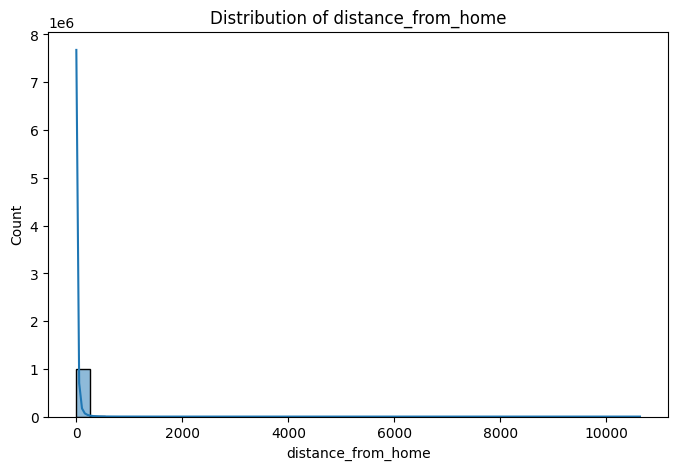

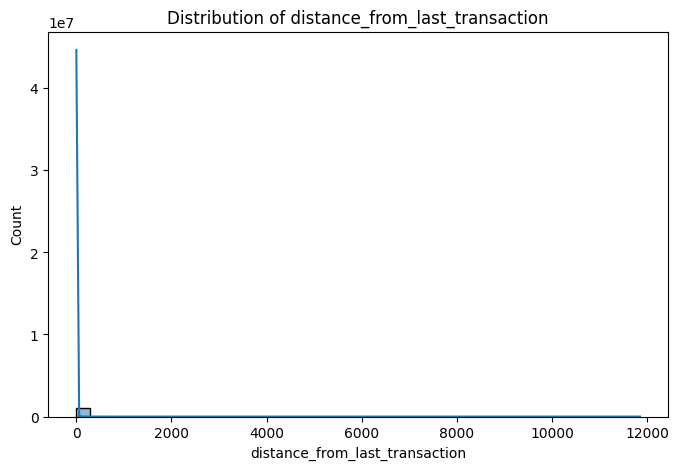

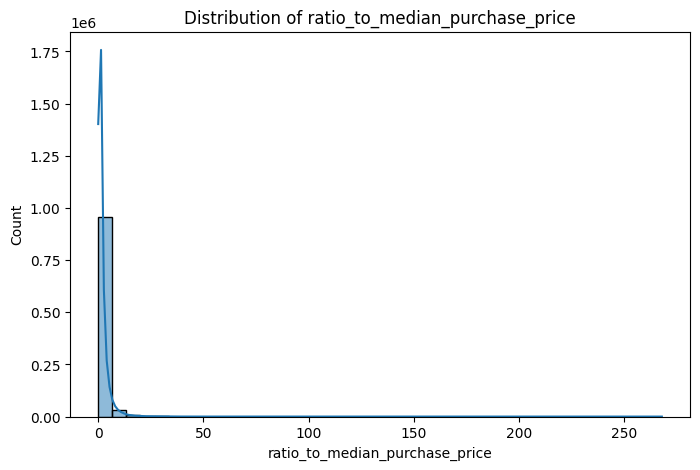

In [36]:
numerical_cols = [
    "distance_from_home",
    "distance_from_last_transaction",
    "ratio_to_median_purchase_price"
]

for col in numerical_cols:

    plt.figure(figsize=(8,5))

    sns.histplot(df[col], bins=40, kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

In [26]:
df["distance_from_home"].describe()

count    1000000.000000
mean          26.628792
std           65.390784
min            0.004874
25%            3.878008
50%            9.967760
75%           25.743985
max        10632.723672
Name: distance_from_home, dtype: float64

In [28]:
df["distance_from_home"].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])

0.00        0.004874
0.25        3.878008
0.50        9.967760
0.75       25.743985
0.90       60.268980
0.95       99.708638
0.99      259.943898
1.00    10632.723672
Name: distance_from_home, dtype: float64

In [29]:
(df["distance_from_home"] > 100).mean() * 100

np.float64(4.9789)

In [38]:
(df["distance_from_home"] > 100).sum()

np.int64(49789)

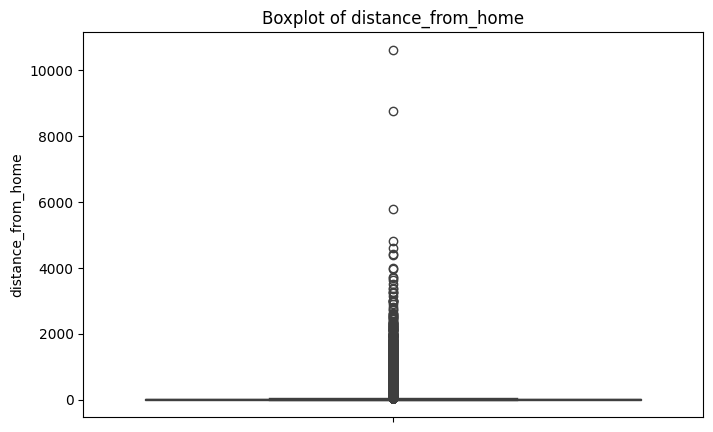

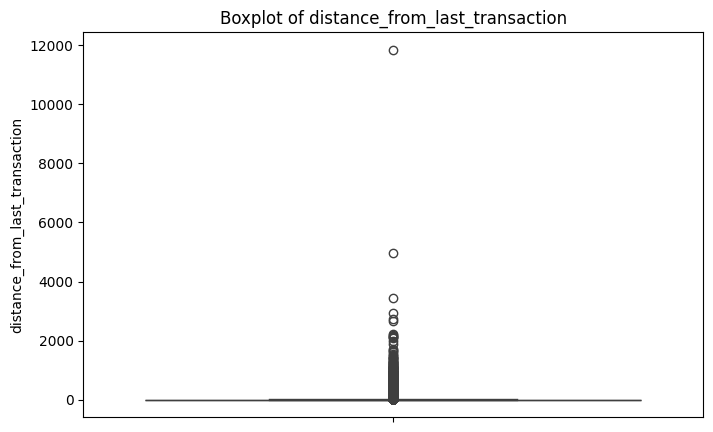

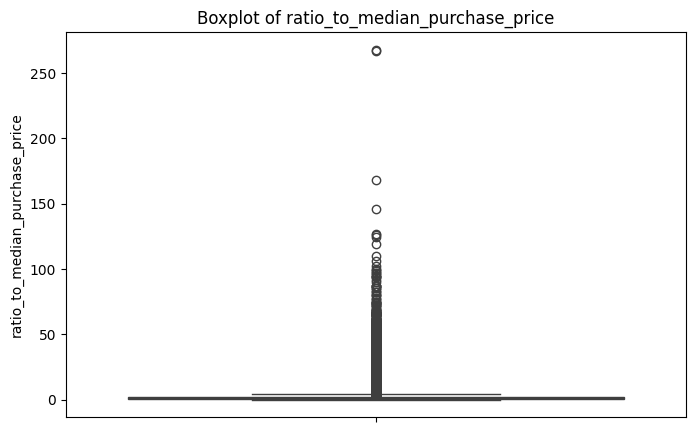

In [40]:
for col in numerical_cols:

    plt.figure(figsize=(8,5))

    sns.boxplot(y=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

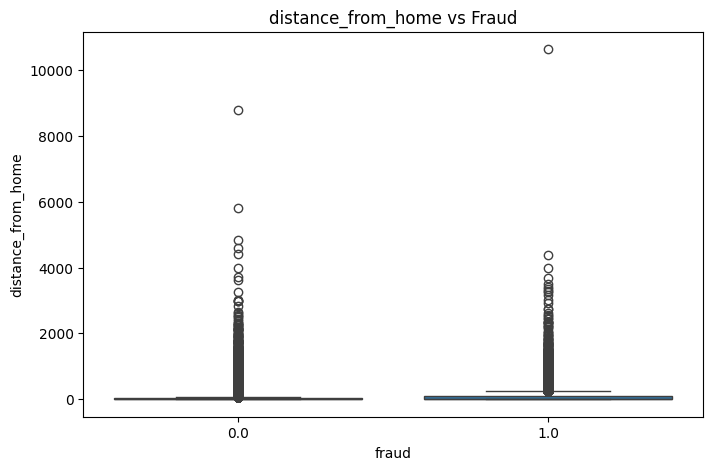

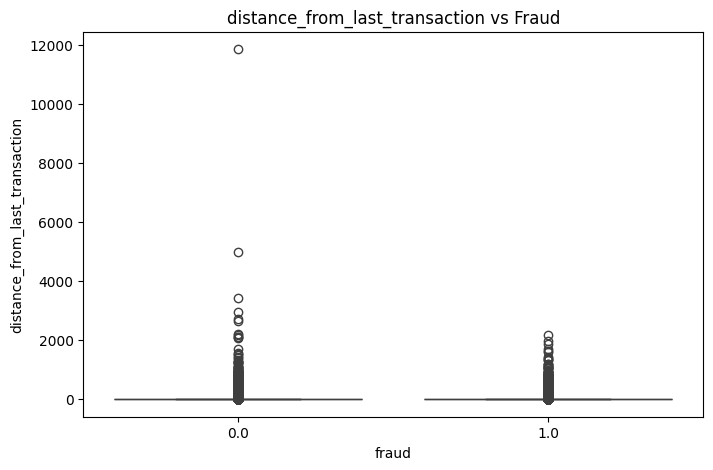

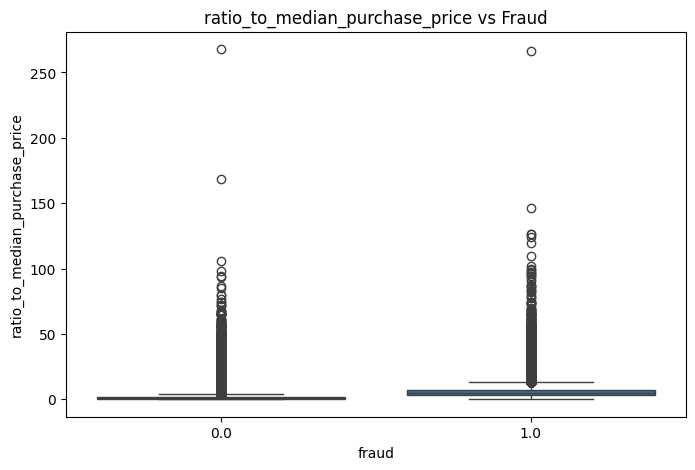

In [39]:
for col in numerical_cols:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="fraud",
        y=col
    )

    plt.title(f"{col} vs Fraud")

    plt.show()

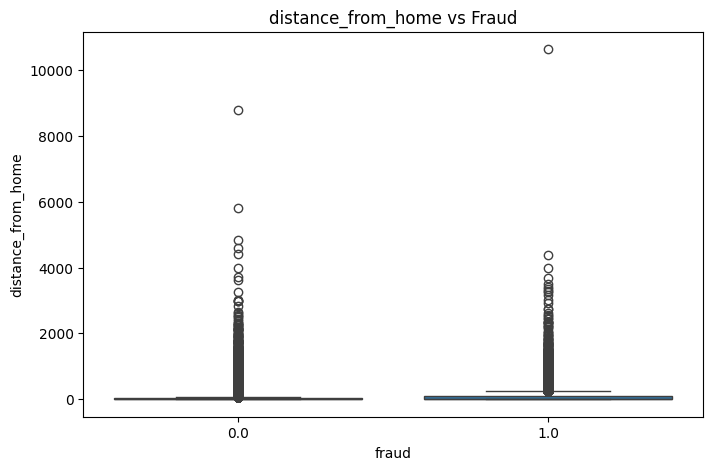

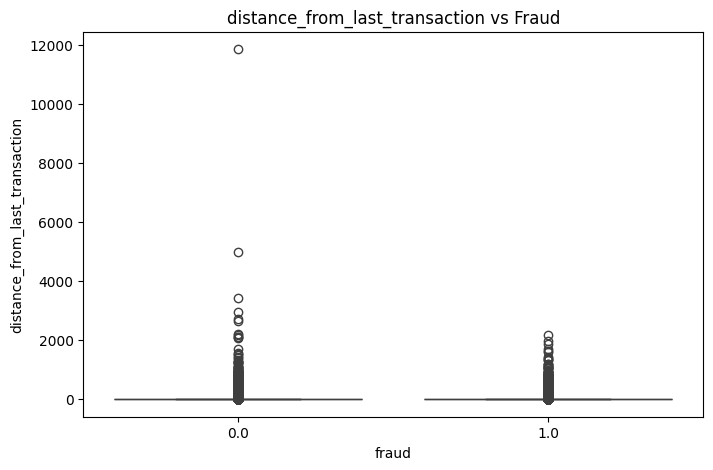

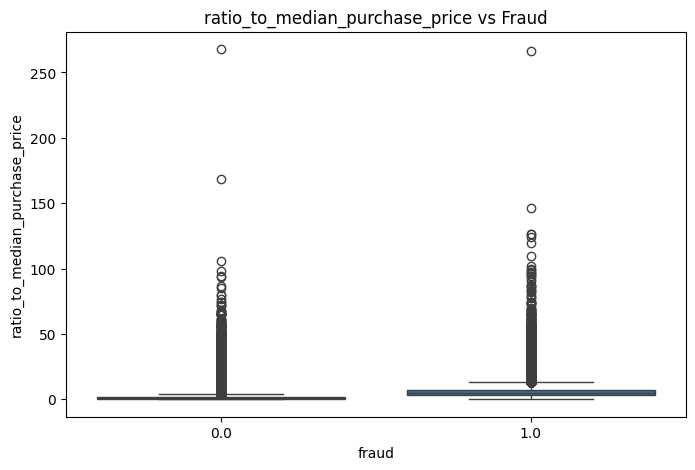

In [41]:
for col in numerical_cols:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="fraud",
        y=col
    )

    plt.title(f"{col} vs Fraud")

    plt.show()

In [42]:
binary_cols = [
    "repeat_retailer",
    "used_chip",
    "used_pin_number",
    "online_order"
]

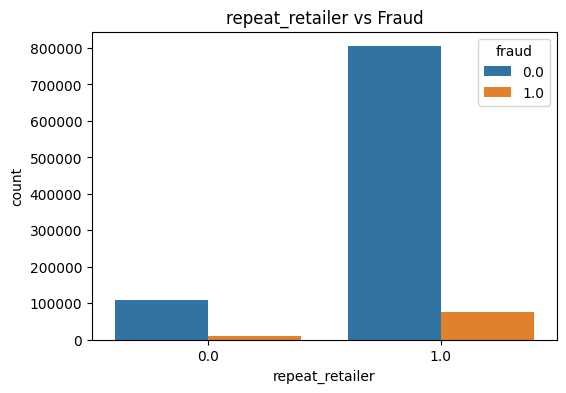

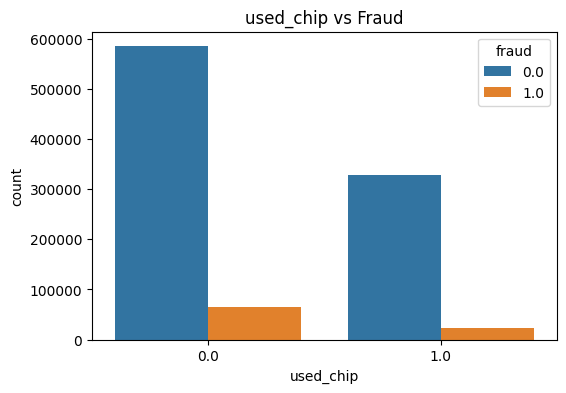

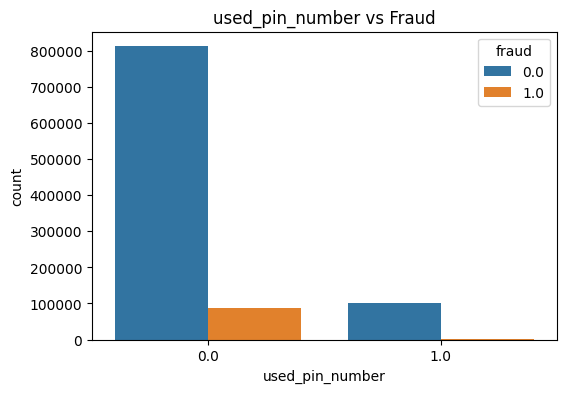

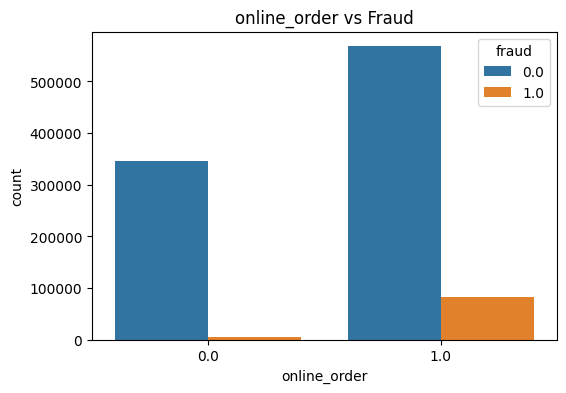

In [43]:
for col in binary_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=col,
        hue="fraud"
    )

    plt.title(f"{col} vs Fraud")

    plt.show()

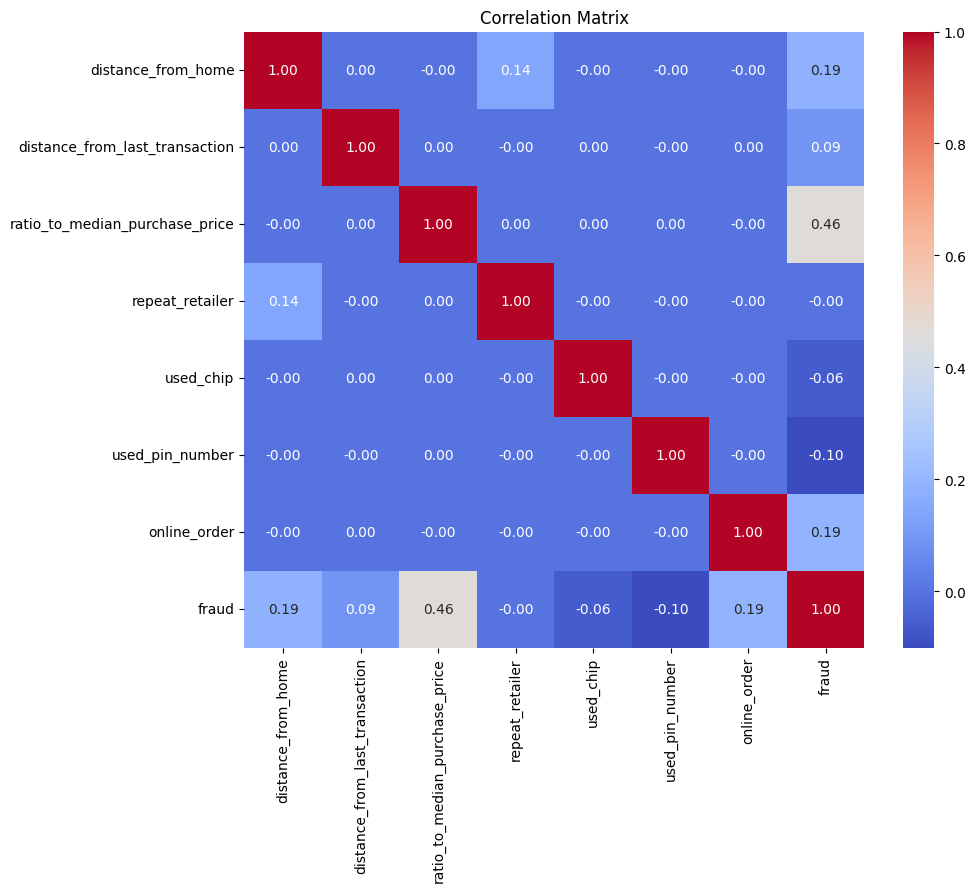

In [44]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [45]:
df.groupby("fraud")[
    [
        "distance_from_home",
        "distance_from_last_transaction",
        "ratio_to_median_purchase_price"
    ]
].mean()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price
fraud,,,
0.0,22.832976,4.301391,1.423642
1.0,66.261876,12.712185,6.006323


## Key Findings

- The dataset contains one million transactions with no missing values.
- The target variable is highly imbalanced.
- Numerical variables are right-skewed with several extreme values.
- Fraudulent transactions exhibit different numerical characteristics compared to legitimate transactions.
- Binary variables such as online orders, chip usage, and PIN usage show distinct fraud patterns.
- Correlation analysis reveals relationships between several transaction features.
- These insights will guide preprocessing and feature engineering before model training.